# 01 — Exploratory analysis: BAF account-opening fraud

**Questions this notebook answers**
1. How rare is fraud, and is it stable month to month? (drives metric choice and the time split)
2. Where is the `-1` missingness, and is *being missing* itself predictive?
3. Which identity/verification signals differ between fraud and legitimate applications? (hypothesis tests)
4. Does anything shift in months 6–7 that a model trained on 0–5 wouldn't have seen?

Dataset: BAF `Base` (Jesus et al., NeurIPS 2022) — 1M synthetic applications, 8 months.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from fraud_monitor import config

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#9a9995"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .25, "axes.titleweight": "bold"})
df = pd.read_csv(config.RAW_CSV)
df.shape

(1000000, 32)

## 1. Prevalence and class balance

Overall fraud rate: 1.103%  (11,029 of 1,000,000)


,n,fraud_rate
month,,
0,"132,440",1.133%
1,"127,620",0.939%
2,"136,979",0.875%
3,"150,936",0.922%
4,"127,691",1.137%
5,"119,323",1.183%
6,"108,168",1.341%
7,"96,843",1.475%


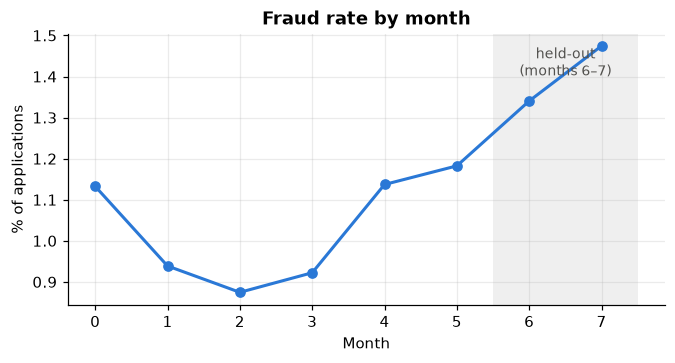

In [2]:
prev = df.groupby("month")["fraud_bool"].agg(n="size", fraud_rate="mean")
print(f"Overall fraud rate: {df.fraud_bool.mean():.3%}  ({df.fraud_bool.sum():,} of {len(df):,})")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(prev.index, prev.fraud_rate * 100, color=BLUE, lw=2, marker="o", ms=6)
ax.axvspan(5.5, 7.5, color=GREY, alpha=.15, lw=0)
ax.text(6.5, ax.get_ylim()[1]*.98, "held-out\n(months 6–7)", ha="center", va="top", color="#52514e", fontsize=9)
ax.set(title="Fraud rate by month", xlabel="Month", ylabel="% of applications")
prev.style.format({"fraud_rate": "{:.3%}", "n": "{:,}"})

**Takeaways.** ~1.1% positive class, so accuracy is meaningless (predict-all-zero scores 98.9%). We evaluate on
*recall at a fixed false-positive rate* — the way a fraud-ops team actually budgets reviewer capacity.
Prevalence rises from 0.9% (month 2) to 1.5% (month 7): the held-out months are harder, not just later.

## 2. Missingness: the `-1` sentinel

In [3]:
sentinel_cols = ["prev_address_months_count", "current_address_months_count", "bank_months_count",
                 "device_distinct_emails_8w", "session_length_in_minutes", "intended_balcon_amount"]
miss = pd.DataFrame({
    "pct_missing": [(df[c] < 0).mean() for c in sentinel_cols],
    "fraud_rate_if_missing": [df.loc[df[c] < 0, "fraud_bool"].mean() for c in sentinel_cols],
    "fraud_rate_if_present": [df.loc[df[c] >= 0, "fraud_bool"].mean() for c in sentinel_cols],
}, index=sentinel_cols)
miss["lift"] = miss.fraud_rate_if_missing / miss.fraud_rate_if_present
miss.sort_values("pct_missing", ascending=False).style.format({"pct_missing": "{:.1%}", "fraud_rate_if_missing": "{:.2%}",
                                                             "fraud_rate_if_present": "{:.2%}", "lift": "{:.2f}x"})

,pct_missing,fraud_rate_if_missing,fraud_rate_if_present,lift
intended_balcon_amount,74.3%,1.31%,0.50%,2.64x
prev_address_months_count,71.3%,1.42%,0.31%,4.56x
bank_months_count,25.4%,1.63%,0.92%,1.77x
current_address_months_count,0.4%,0.33%,1.11%,0.30x
session_length_in_minutes,0.2%,0.89%,1.10%,0.81x
device_distinct_emails_8w,0.0%,1.11%,1.10%,1.01x


**Takeaways.** `prev_address_months_count` is missing for ~71% of rows and `bank_months_count` for ~25%.
Missing previous-address history carries fraud lift, so the SQL feature layer keeps an explicit
`prev_address_missing` flag and NULLs the sentinel rather than letting a tree learn `-1` as a magic number.
`intended_balcon_amount` uses negative values as "not provided" too — ~74% of rows.

## 3. Hypothesis tests: which signals separate fraud from legitimate?

Binary/categorical features → chi-square test of independence. Continuous features → Mann–Whitney U
(distributions are skewed, so no t-test). With n = 1M almost everything is "significant"; the effect size
column is what matters.

In [4]:
cat_feats = ["email_is_free", "phone_home_valid", "phone_mobile_valid", "foreign_request", "has_other_cards",
             "keep_alive_session", "device_os", "payment_type", "employment_status", "housing_status", "source"]
rows = []
for c in cat_feats:
    ct = pd.crosstab(df[c], df.fraud_bool)
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum(); k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k))
    rate = df.groupby(c).fraud_bool.mean()
    rows.append({"feature": c, "levels": ct.shape[0], "chi2": chi2, "p": p, "cramers_v": cramers_v,
                 "max_fraud_rate": rate.max(), "min_fraud_rate": rate.min()})
chi = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
chi.style.format({"chi2": "{:,.0f}", "p": "{:.1e}", "cramers_v": "{:.3f}", "max_fraud_rate": "{:.2%}", "min_fraud_rate": "{:.2%}"}).hide(axis="index")

feature,levels,chi2,p,cramers_v,max_fraud_rate,min_fraud_rate
housing_status,7,"13,203",0.0e+00,0.115,3.75%,0.34%
device_os,5,"6,479",0.0e+00,0.080,2.47%,0.52%
keep_alive_session,2,"2,529",0.0e+00,0.050,1.72%,0.65%
employment_status,7,"1,572",0.0e+00,0.040,2.47%,0.19%
payment_type,5,"1,528",0.0e+00,0.039,1.67%,0.35%
has_other_cards,2,"1,235",1.4e-270,0.035,1.30%,0.42%
phone_home_valid,2,"1,233",3.6e-270,0.035,1.41%,0.67%
email_is_free,2,770,1.8e-169,0.028,1.38%,0.80%
foreign_request,2,284,9.8e-64,0.017,2.20%,1.07%
phone_mobile_valid,2,173,1.4e-39,0.013,1.49%,1.05%


In [5]:
num_feats = ["name_email_similarity", "credit_risk_score", "income", "customer_age", "proposed_credit_limit",
             "days_since_request", "velocity_6h", "velocity_24h", "velocity_4w", "zip_count_4w",
             "date_of_birth_distinct_emails_4w", "bank_branch_count_8w"]
rows = []
f, l = df[df.fraud_bool == 1], df[df.fraud_bool == 0]
for c in num_feats:
    u, p = stats.mannwhitneyu(f[c], l[c])
    auc = u / (len(f) * len(l))           # common-language effect size: P(fraud value > legit value)
    rows.append({"feature": c, "median_fraud": f[c].median(), "median_legit": l[c].median(), "p": p, "P(fraud > legit)": auc})
mw = pd.DataFrame(rows).assign(sep=lambda d: (d["P(fraud > legit)"] - .5).abs()).sort_values("sep", ascending=False).drop(columns="sep")
mw.style.format({"median_fraud": "{:,.2f}", "median_legit": "{:,.2f}", "p": "{:.1e}", "P(fraud > legit)": "{:.3f}"}).hide(axis="index")

feature,median_fraud,median_legit,p,P(fraud > legit)
credit_risk_score,178.00,122.00,0.0e+00,0.666
customer_age,40.00,30.00,0.0e+00,0.656
proposed_credit_limit,500.00,200.00,0.0e+00,0.639
income,0.80,0.60,0.0e+00,0.636
date_of_birth_distinct_emails_4w,7.00,9.00,0.0e+00,0.374
name_email_similarity,0.29,0.49,3.1e-304,0.397
bank_branch_count_8w,2.00,9.00,4.5e-228,0.411
velocity_6h,"4,916.46","5,324.54",3.9e-61,0.454
days_since_request,0.01,0.02,8.0e-46,0.461
velocity_4w,"4,827.70","4,914.58",1.1e-41,0.463


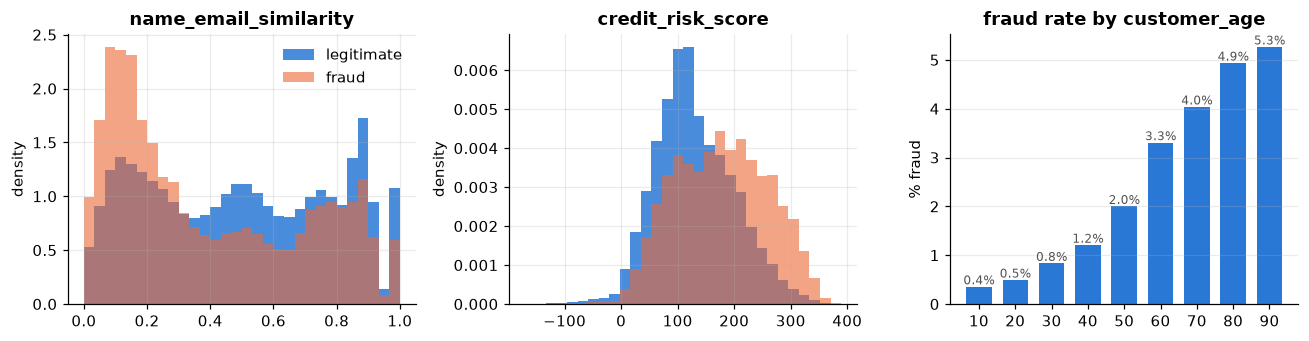

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, c in zip(axes[:2], ["name_email_similarity", "credit_risk_score"]):
    bins = np.histogram_bin_edges(df[c], bins=30)
    ax.hist(l[c], bins=bins, density=True, color=BLUE, alpha=.85, label="legitimate")
    ax.hist(f[c], bins=bins, density=True, color=ORANGE, alpha=.6, label="fraud")
    ax.set(title=c, ylabel="density")
axes[0].legend(frameon=False)
age = df.groupby("customer_age").fraud_bool.agg(rate="mean", n="size")
axes[2].bar(age.index, age.rate * 100, width=7, color=BLUE)
for x, r in age.rate.items():
    axes[2].text(x, r * 100 + .05, f"{r:.1%}", ha="center", fontsize=8, color="#52514e")
axes[2].set(title="fraud rate by customer_age", ylabel="% fraud", xticks=age.index)
axes[2].grid(axis="x", visible=False)
plt.tight_layout()

**Takeaways.**
- The strongest continuous signals all point the same way: fraudulent applications look *more* creditworthy —
  higher `credit_risk_score` (median 178 vs 122), higher `proposed_credit_limit` (500 vs 200), higher `income`
  (0.8 vs 0.6) and older `customer_age` (median 40 vs 30; fraud rate climbs from 0.5% at age 20 to 3–5% at 60+). That's the synthetic-identity pattern: fabricated profiles
  are built to pass credit checks.
- `name_email_similarity` is lower for fraud (median 0.29 vs 0.49) — the email doesn't match the name on the application.
- Among categoricals, `housing_status` (V = 0.115) and `device_os` (0.080) separate most. The verification flags
  (`phone_home_valid`, `email_is_free`, `foreign_request`) are significant but weak on their own (V < 0.04).
- `customer_age` separating fraud from legitimate is the root of the fairness finding in the model card: fraud
  labels skew older, so a model that uses age (directly or through proxies like credit limit and income) will
  block older *legitimate* applicants more often.
- Every Cramér's V is below 0.12 and every P(fraud > legit) is within 0.17 of 0.5: no single feature is decisive,
  which is why a multivariate model is needed.

## 4. What changes in the held-out months?

In [7]:
tr, pr = df[df.month <= 5], df[df.month >= 6]
shift = pd.DataFrame({
    "train_median": tr[num_feats].median(), "prod_median": pr[num_feats].median(),
    "train_mean": tr[num_feats].mean(), "prod_mean": pr[num_feats].mean()})
shift["mean_shift_%"] = (shift.prod_mean / shift.train_mean - 1) * 100
shift.sort_values("mean_shift_%", key=abs, ascending=False).style.format("{:,.2f}")

,train_median,prod_median,train_mean,prod_mean,mean_shift_%
velocity_6h,"5,961.19","3,609.34","6,148.45","3,791.72",-38.33
zip_count_4w,"1,361.00",975.00,"1,681.88","1,149.30",-31.67
velocity_24h,"5,020.41","3,200.85","5,100.33","3,487.97",-31.61
velocity_4w,"5,117.56","3,698.12","5,140.89","3,752.83",-27.00
date_of_birth_distinct_emails_4w,9.00,7.00,10.00,7.60,-23.99
days_since_request,0.02,0.01,1.07,0.87,-18.20
bank_branch_count_8w,10.00,9.00,191.31,157.42,-17.72
credit_risk_score,120.00,131.00,127.29,145.33,14.17
income,0.60,0.70,0.55,0.62,13.67
proposed_credit_limit,200.00,200.00,525.60,478.05,-9.05


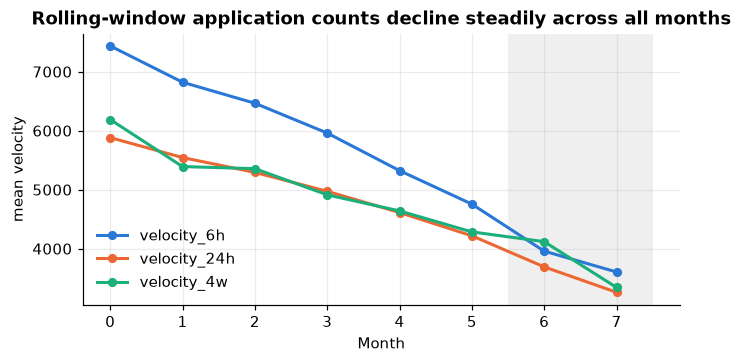

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
vm = df.groupby("month")[["velocity_6h", "velocity_24h", "velocity_4w"]].mean()
for c, col in zip(vm.columns, [BLUE, ORANGE, "#1baf7a"]):
    ax.plot(vm.index, vm[c], lw=2, marker="o", ms=5, color=col, label=c)
ax.axvspan(5.5, 7.5, color=GREY, alpha=.15, lw=0)
ax.set(title="Rolling-window application counts decline steadily across all months", xlabel="Month", ylabel="mean velocity")
ax.legend(frameon=False);

**Takeaways.** The three `velocity_*` features (applications per window) decline steadily across all eight
months — months 6–7 are 27–38% below the training-period mean and sit at or below the *lowest* values the model
saw in training. This is a volume trend, not a behaviour change, but the effect is the same: production inputs
fall outside the training range. `monitor.py` flags exactly this (PSI 0.9–2.9 on the raw velocities, 0.4 on
`zip_count_4w`), and it's why `features.sql` adds velocity *ratios*, which are far more stable (PSI ≈ 0.15).
Prevalence also rises through months 6–7, so recall in production is expected to sit a few points below
validation even without concept drift.

## Decisions carried into the pipeline
| Finding | Decision |
|---|---|
| 1.1% prevalence | Evaluate on recall @ 5% FPR; class-weighted training |
| `-1` sentinels with fraud lift | NULL them in SQL + explicit `*_missing` flag |
| Velocity counts shift with volume | Add ratio features; PSI-monitor the raw ones |
| Age is predictive of the label | Keep age *out* of the model's inputs? — decided in the model card |